In [2]:
# Happy Sad classification

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!nvidia-smi

Wed Sep 16 18:30:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [5]:
img= image.load_img('/content/drive/MyDrive/CNN- Happy or Sad/training/happy/20181107_221706.jpg')

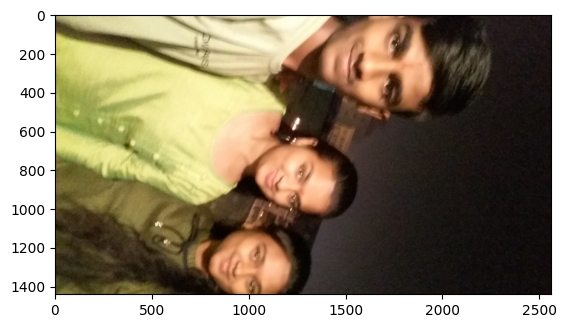

In [6]:
plt.imshow(img)

In [7]:
i1=cv2.imread('/content/drive/MyDrive/CNN- Happy or Sad/training/happy/20181107_221706.jpg')
i1
# 3 dimension matrix created
#range value from 0-255

array([[[ 20,  33,  25],
        [ 18,  31,  23],
        [ 20,  31,  23],
        ...,
        [  9,  10,  20],
        [  8,  10,  18],
        [  7,   9,  17]],

       [[ 15,  28,  20],
        [ 17,  30,  22],
        [ 20,  31,  23],
        ...,
        [ 10,  11,  21],
        [  9,  11,  19],
        [  9,  11,  19]],

       [[ 15,  28,  20],
        [ 18,  29,  21],
        [ 20,  31,  23],
        ...,
        [ 10,  11,  21],
        [  9,  11,  19],
        [ 10,  12,  20]],

       ...,

       [[137, 186, 188],
        [137, 186, 188],
        [137, 185, 189],
        ...,
        [ 25,  82, 103],
        [ 25,  82, 103],
        [ 27,  84, 105]],

       [[138, 187, 189],
        [138, 187, 189],
        [136, 185, 187],
        ...,
        [ 26,  83, 104],
        [ 25,  82, 103],
        [ 25,  82, 104]],

       [[139, 188, 190],
        [138, 187, 189],
        [135, 184, 186],
        ...,
        [ 28,  85, 106],
        [ 28,  85, 106],
        [ 28,  85, 107]]

In [8]:
i1.shape

(2560, 1440, 3)

In [9]:
train=ImageDataGenerator(rescale=1/200)
validation=ImageDataGenerator(rescale=1/200)
# to scale all image i need to divide with 255
# we need to resize image using 200,200 pixel

In [10]:
train_dataset=train.flow_from_directory(
    '/content/drive/MyDrive/CNN- Happy or Sad/training',
    target_size=(200,200),
    batch_size=32,
    class_mode='binary')
validation_dataset=train.flow_from_directory(
    '/content/drive/MyDrive/CNN- Happy or Sad/validation',
    target_size=(200,200),
    batch_size=32,
    class_mode='binary')

Found 33 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [11]:
train_dataset.class_indices

{'happy': 0, 'not happy': 1}

In [12]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int32)

In [13]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),
    #
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    #
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    #
    tf.keras.layers.Flatten(),
    #
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy']
              )

In [15]:
model_fit = model.fit(train_dataset,epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3636 - loss: 0.6806
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8182 - loss: 5.9594
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7879 - loss: 0.7615
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8182 - loss: 0.5506
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8182 - loss: 0.4003
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8182 - loss: 0.6781
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8182 - loss: 0.5924
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8182 - loss: 0.7981
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8182 - loss: 0.4785
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8788 - loss: 0.6252
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8182 - loss: 0.5199
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8182 - loss: 0.4648
Epoch 13/20
2/

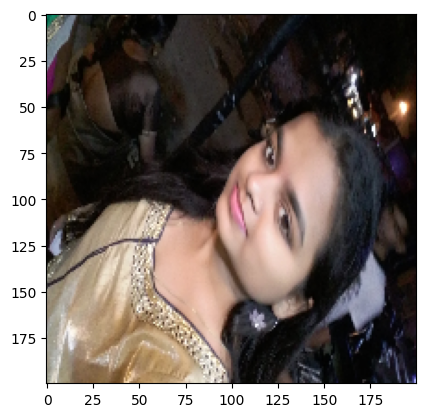

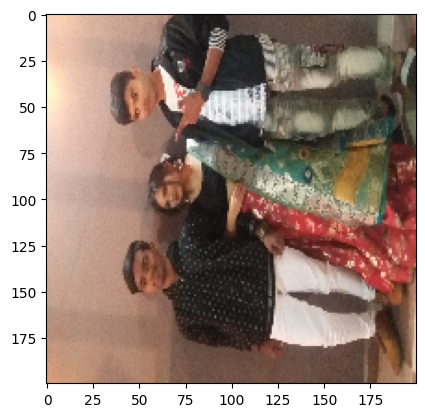

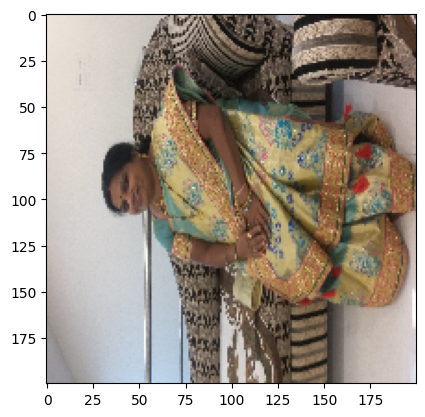

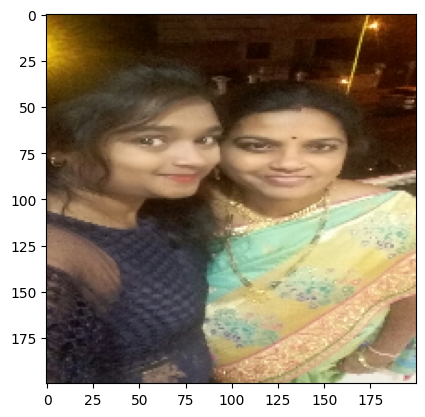

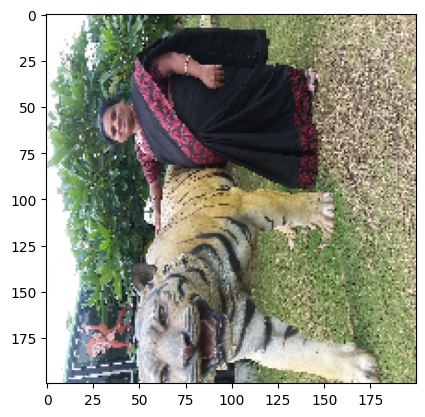

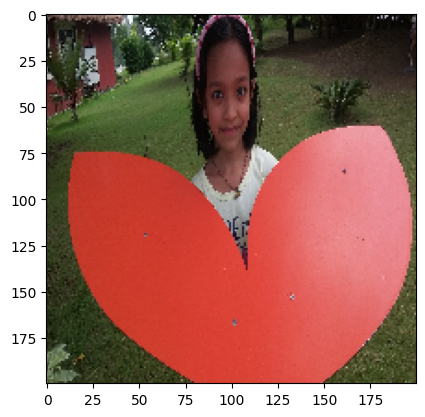

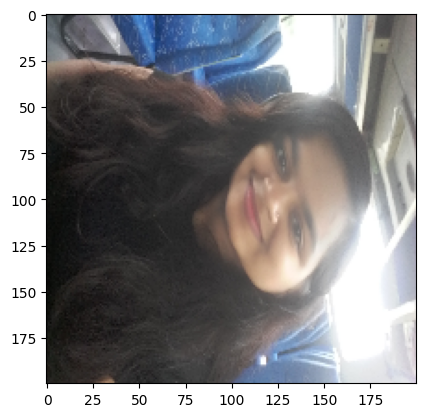

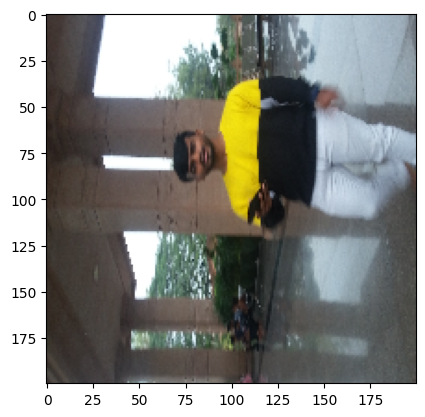

In [16]:
dir_path='/content/drive/MyDrive/CNN- Happy or Sad/testing'

for i in os.listdir(dir_path):
  img=image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

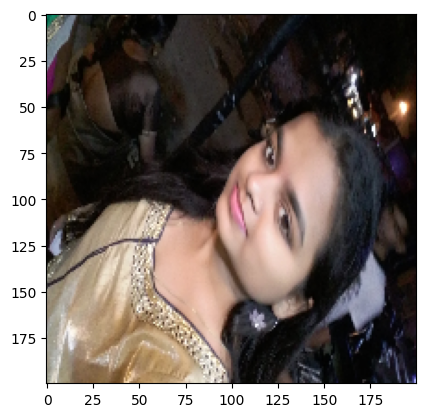

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i am happy


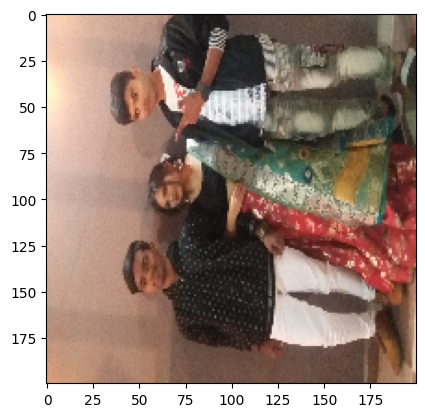

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
i am happy


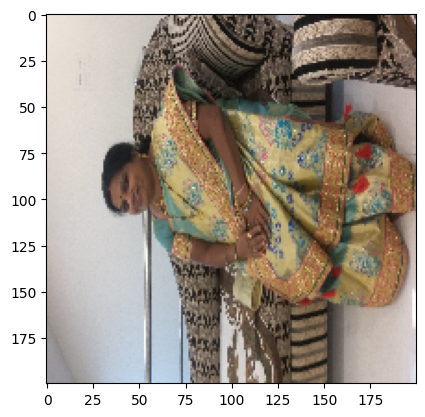

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
i am happy


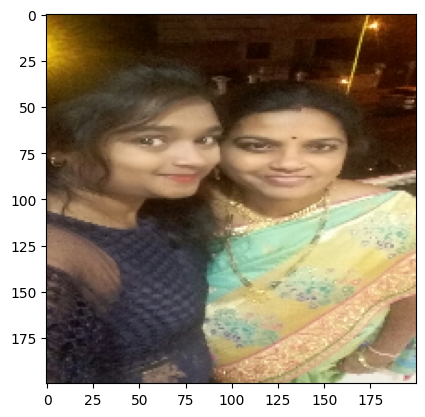

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
i am happy


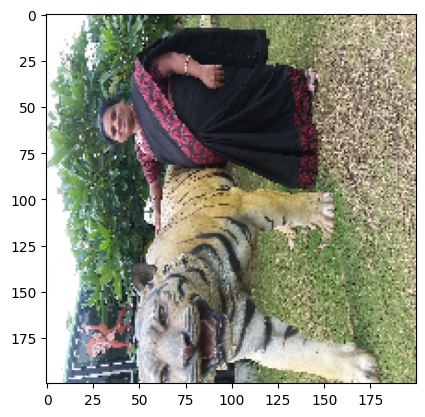

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
i am happy


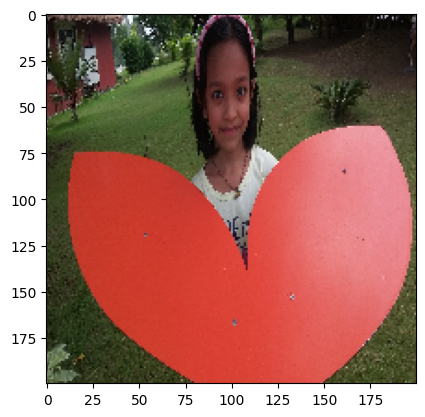

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
i am happy


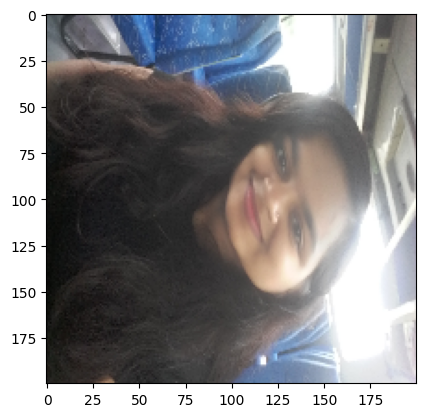

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
i am happy


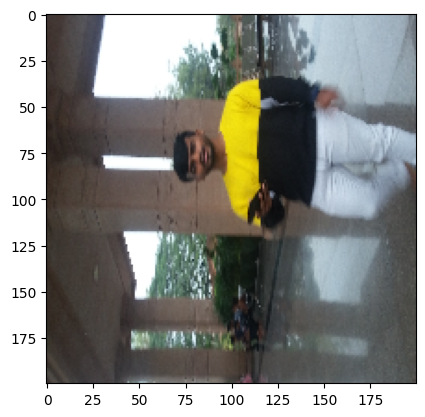

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
i am happy


In [23]:
#def predict_mood(img):
dir_path = '/content/drive/MyDrive/CNN- Happy or Sad/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val == 0:
        print( 'i am happy')
    else:
        print('i am not happy')

In [18]:
!pip install -q gradio

In [26]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
  # Resize the image to (200, 200) as expected by the model
  img = image.resize((200, 200)) # Convert the image to a numpy array
  x = np.array(img)
  # Expand dimensions to create a batch of 1 image
  x = np.expand_dims(x, axis=0)
  # Normalize the image (if the model was trained with normalized inputs)
  # The model was trained with rescale=1/200, so we should apply the same scaling here.
  x = x / 200.0
  # Make prediction
  val = model.predict(x)[0][0]
  # Interpret the prediction
  if val < 0.5:
    return 'Happy'
  else:
    return 'Not Happy'

In [27]:
#import gradio as gr
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil", label="Upload an image"),
                     outputs=gr.Text(label="Predicted Mood"),
                     title="Mood Classification (Happy/Not Happy)",
                     description="Upload an image to classify if the person is happy or not happy.")

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://994ee3f32b7fc4f08d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
